# Notebook operativo SCOPE vs Groq (benchmark reale) + KPI decisionali

Questo notebook e pensato per essere pratico e immediato:
- una sola cella di configurazione iniziale
- benchmark reale multi-provider (niente simulazioni)
- KPI decisionali con grafici rapidi

Percorso consigliato:
1. Esegui la sezione **SETUP UNICO** e imposta tutte le variabili.
2. Esegui il benchmark reale Groq vs SCOPE.
3. Guarda i grafici di explainability del benchmark.
4. Esegui KPI decisionali e relativi grafici.

Output principali:
- `OUTPUT_DIR/ab_results.json`
- `OUTPUT_DIR/model_throughput_log.json`
- `OUTPUT_DIR/kpi_decision_report.json`

## Sezione HPC SSH/SLURM (opzionale)

Questa parte e utile solo se vuoi test infrastrutturali diretti su SCOPE via SSH + SLURM (coda, CPU/GPU, job script).

Se il tuo obiettivo principale e confrontare modelli Groq vs SCOPE via endpoint API, puoi saltare questa sezione e usare solo:
- setup unico
- benchmark reale multi-provider
- KPI + grafici

In [ ]:
import json
import os
import re
import shlex
import subprocess
import time
import urllib.error
import urllib.request
from pathlib import Path

from dotenv import load_dotenv

def find_project_root() -> Path:
    cwd = Path.cwd().resolve()
    for p in [cwd, *cwd.parents]:
        if (p / "pyproject.toml").exists():
            return p
    return cwd

PROJECT_ROOT = find_project_root()
ENV_PATH = PROJECT_ROOT / ".env"
if ENV_PATH.exists():
    load_dotenv(ENV_PATH, override=False)

def resolve_notebook_path(relative_name: str) -> Path:
    cwd = Path.cwd()
    if (cwd / "scope_hpc_feasibility_tests.ipynb").exists():
        return cwd / relative_name
    if (cwd / "notebooks" / "scope_hpc_feasibility_tests.ipynb").exists():
        return cwd / "notebooks" / relative_name
    if (cwd / "notebooks").exists():
        return cwd / "notebooks" / relative_name
    return cwd / relative_name

def unique_models(*groups):
    out = []
    for group in groups:
        for model in group:
            m = str(model).strip()
            if m and m not in out:
                out.append(m)
    return out

# ------------------------------------------------------------
# SETUP UNICO: imposta qui tutte le variabili del notebook
# ------------------------------------------------------------

LEXCAUSA_GROQ_MODELS = [
    "qwen/qwen3-32b",
    "llama-3.3-70b-versatile",
    "openai/gpt-oss-20b",
    "openai/gpt-oss-120b",
]

SCOPE_EXTRA_MODELS = [
    "meta-llama/llama-4-maverick-17b-128e-instruct",
    "meta-llama/llama-4-scout-17b-16e-instruct",
    "deepseek-ai/DeepSeek-R1-Distill-Qwen-14B",
    "deepseek-ai/DeepSeek-R1-Distill-Llama-8B",
]

USER_CONFIG = {
    "paths": {
        "output_dir": str(resolve_notebook_path(".scope_hpc_outputs")),
        "tmp_dir": str(resolve_notebook_path(".scope_hpc_tmp")),
    },
    "hpc": {
        "dry_run": True,
        "user": os.getenv("SCOPE_HPC_USER", "<USERNAME>"),
        "host": os.getenv("SCOPE_HPC_HOST", "<HPC_HOST>"),
        "remote_workdir": os.getenv("SCOPE_HPC_REMOTE_WORKDIR", "/ibiscostorage/<USERNAME>/lexcausa_bench"),
        "cpu_partition": "sequential",
        "gpu_partition": "gpus",
        "cpus_per_task": 8,
        "gpus": 1,
        "time_limit": "00:20:00",
    },
    "benchmark": {
        "system_prompt": "Sei un assistente legale tecnico, sintetico e rigoroso.",
        "temperature": 0.2,
        "max_tokens": 768,
        "timeout_s": 180,
        "prompts": [
            "Valuta se la revoca in autotutela e adeguatamente motivata in presenza di affidamento qualificato del privato.",
            "Nel caso di inadempimento contrattuale, quando e proporzionata la risoluzione rispetto alla riduzione del prezzo?",
            "Esamina il nesso causale in responsabilita da custodia quando interviene un fattore esterno imprevedibile.",
            "Quando la violazione procedimentale e non invalidante ai sensi dell art. 21-octies L. 241/1990?",
            "Confronta soglia probatoria penale e civile in un caso con fatti in parte sovrapposti.",
            "Analizza se il danno e prevedibile ex ante ai fini dell art. 1225 c.c. in un caso di ritardo esecutivo.",
            "Valuta il concorso colposo del danneggiato e il suo impatto sulla quantificazione del risarcimento.",
            "Distingui tra causa sopravvenuta da sola sufficiente e semplice concausa in ambito penale.",
        ],
    },
    "providers": {
        "groq": {
            "enabled": True,
            "endpoint": os.getenv("GROQ_ENDPOINT", "https://api.groq.com/openai/v1/chat/completions"),
            "api_key_env": "GROQ_API_KEY",
            "extra_headers_env": "",
            "models": LEXCAUSA_GROQ_MODELS,
        },
        "scope": {
            "enabled": True,
            "endpoint": os.getenv("SCOPE_ENDPOINT", "https://INSERISCI_ENDPOINT_SCOPE/v1/chat/completions"),
            "api_key_env": "SCOPE_API_KEY",
            "extra_headers_env": "SCOPE_EXTRA_HEADERS_JSON",
            "models": unique_models(LEXCAUSA_GROQ_MODELS, SCOPE_EXTRA_MODELS),
        },
    },
    "kpi": {
        "thresholds": {
            "queue_wait_p95_max_min": 20.0,
            "throughput_p95_min_tps": 12.0,
            "scope_vs_groq_cost_ratio_max": 1.15,
        },
        "defaults": {
            "queue_rows": [
                {"submit_ts": "2026-04-20T09:00:00", "start_ts": "2026-04-20T09:07:00"},
                {"submit_ts": "2026-04-20T10:00:00", "start_ts": "2026-04-20T10:11:00"},
                {"submit_ts": "2026-04-20T11:00:00", "start_ts": "2026-04-20T11:06:00"},
            ],
            "throughput_rows": [
                {"provider": "groq", "model": "qwen/qwen3-32b", "generated_tokens": 1200, "elapsed_s": 70.0},
                {"provider": "scope", "model": "deepseek-ai/DeepSeek-R1-Distill-Qwen-14B", "generated_tokens": 1800, "elapsed_s": 130.0},
            ],
            "cost_inputs": {
                "scope_infra_eur_month": 0.0,
                "scope_gpu_hours_month": 120.0,
                "scope_gpu_hour_eur": 0.0,
                "scope_ops_hours_month": 12.0,
                "groq_api_eur_month": 250.0,
                "groq_ops_hours_month": 3.0,
                "ops_hour_eur": 35.0,
            },
        },
    },
}

# Variabili operative condivise (compatibilita con celle esistenti)
OUTPUT_DIR = Path(USER_CONFIG["paths"]["output_dir"])
TMP_DIR = Path(USER_CONFIG["paths"]["tmp_dir"])
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
TMP_DIR.mkdir(parents=True, exist_ok=True)

SCOPE_USER = USER_CONFIG["hpc"]["user"]
SCOPE_HOST = USER_CONFIG["hpc"]["host"]
REMOTE_WORKDIR = USER_CONFIG["hpc"]["remote_workdir"]

CONFIG = {
    "dry_run": USER_CONFIG["hpc"]["dry_run"],
    "host": SCOPE_HOST,
    "user": SCOPE_USER,
    "remote_workdir": REMOTE_WORKDIR,
    "cpu_partition": USER_CONFIG["hpc"]["cpu_partition"],
    "gpu_partition": USER_CONFIG["hpc"]["gpu_partition"],
    "cpus_per_task": USER_CONFIG["hpc"]["cpus_per_task"],
    "gpus": USER_CONFIG["hpc"]["gpus"],
    "time_limit": USER_CONFIG["hpc"]["time_limit"],
}

AB_CONFIG = {
    "temperature": USER_CONFIG["benchmark"]["temperature"],
    "max_tokens": USER_CONFIG["benchmark"]["max_tokens"],
    "timeout_s": USER_CONFIG["benchmark"]["timeout_s"],
    "system_prompt": USER_CONFIG["benchmark"]["system_prompt"],
    "providers": USER_CONFIG["providers"],
}

LEGAL_PROMPTS = list(USER_CONFIG["benchmark"]["prompts"])
KPI_THRESHOLDS = dict(USER_CONFIG["kpi"]["thresholds"])
KPI_DEFAULTS = dict(USER_CONFIG["kpi"]["defaults"])

print("Setup unico caricato")
print(json.dumps({
    "output_dir": str(OUTPUT_DIR),
    "tmp_dir": str(TMP_DIR),
    "hpc_dry_run": CONFIG["dry_run"],
    "groq_models": AB_CONFIG["providers"]["groq"]["models"],
    "scope_models": AB_CONFIG["providers"]["scope"]["models"],
    "n_prompts": len(LEGAL_PROMPTS),
    "kpi_thresholds": KPI_THRESHOLDS,
}, indent=2))

Setup unico caricato
{
  "output_dir": "/Users/l.catello/Library/Mobile Documents/com~apple~CloudDocs/Magistrale Ingegneria Informatica/Tesi/LexCausa/notebooks/.scope_hpc_outputs",
  "tmp_dir": "/Users/l.catello/Library/Mobile Documents/com~apple~CloudDocs/Magistrale Ingegneria Informatica/Tesi/LexCausa/notebooks/.scope_hpc_tmp",
  "hpc_dry_run": true,
  "groq_models": [
    "qwen/qwen3-32b",
    "llama-3.3-70b-versatile",
    "openai/gpt-oss-20b",
    "openai/gpt-oss-120b"
  ],
  "scope_models": [
    "qwen/qwen3-32b",
    "llama-3.3-70b-versatile",
    "openai/gpt-oss-20b",
    "openai/gpt-oss-120b",
    "meta-llama/llama-4-maverick-17b-128e-instruct",
    "meta-llama/llama-4-scout-17b-16e-instruct",
    "deepseek-ai/DeepSeek-R1-Distill-Qwen-14B",
    "deepseek-ai/DeepSeek-R1-Distill-Llama-8B"
  ],
  "n_prompts": 8,
  "kpi_thresholds": {
    "queue_wait_p95_max_min": 20.0,
    "throughput_p95_min_tps": 12.0,
    "scope_vs_groq_cost_ratio_max": 1.15
  }
}


In [ ]:
def run_shell(cmd: str):
    print(f"$ {cmd}")
    if CONFIG["dry_run"]:
        return 0, "", ""
    p = subprocess.run(cmd, shell=True, text=True, capture_output=True)
    return p.returncode, p.stdout, p.stderr


def ssh(remote_cmd: str) -> str:
    user_host = f"{CONFIG['user']}@{CONFIG['host']}"
    return f"ssh {user_host} {shlex.quote(remote_cmd)}"


def scp_to_remote(local_path: Path, remote_path: str) -> str:
    user_host = f"{CONFIG['user']}@{CONFIG['host']}"
    return f"scp {shlex.quote(str(local_path))} {user_host}:{shlex.quote(remote_path)}"


def scp_from_remote(remote_path: str, local_path: Path) -> str:
    user_host = f"{CONFIG['user']}@{CONFIG['host']}"
    return f"scp {user_host}:{shlex.quote(remote_path)} {shlex.quote(str(local_path))}"

In [ ]:
preflight = [
    "hostname",
    "whoami",
    "sinfo -o '%P %a %l %D %T'",
    "squeue -u $USER"
]

for c in preflight:
    cmd = ssh(f"bash -lc {shlex.quote(c)}")
    rc, out, err = run_shell(cmd)
    if not CONFIG["dry_run"]:
        print("STDOUT:")
        print(out.strip())
        if err.strip():
            print("STDERR:")
            print(err.strip())
        print("-" * 60)

In [ ]:
from pathlib import Path

if "TMP_DIR" in globals():
    local_dir = TMP_DIR
else:
    if "resolve_notebook_path" not in globals():
        def resolve_notebook_path(relative_name: str) -> Path:
            cwd = Path.cwd()
            if (cwd / "scope_hpc_feasibility_tests.ipynb").exists():
                return cwd / relative_name
            if (cwd / "notebooks" / "scope_hpc_feasibility_tests.ipynb").exists():
                return cwd / "notebooks" / relative_name
            if (cwd / "notebooks").exists():
                return cwd / "notebooks" / relative_name
            return cwd / relative_name
    local_dir = resolve_notebook_path(".scope_hpc_tmp")

local_dir.mkdir(parents=True, exist_ok=True)

probe_py = '''#!/usr/bin/env python3
import json
import os
import platform
import time

import torch

def bench(device: str, sizes, iters: int):
    out = []
    for n in sizes:
        a = torch.randn((n, n), device=device)
        b = torch.randn((n, n), device=device)
        if device.startswith("cuda"):
            torch.cuda.synchronize()
        t0 = time.perf_counter()
        for _ in range(iters):
            _ = a @ b
        if device.startswith("cuda"):
            torch.cuda.synchronize()
        dt = time.perf_counter() - t0
        gflops = (2.0 * (n ** 3) * iters) / max(dt, 1e-9) / 1e9
        out.append({"size": n, "iters": iters, "seconds": dt, "gflops": gflops})
    return out

torch.set_num_threads(int(os.getenv("SLURM_CPUS_PER_TASK", "1")))

report = {
    "platform": platform.platform(),
    "python": platform.python_version(),
    "torch": torch.__version__,
    "cuda_available": bool(torch.cuda.is_available()),
    "cuda_device_count": int(torch.cuda.device_count()),
    "cpu_bench": bench("cpu", [1024, 2048, 4096], 3),
}

if torch.cuda.is_available():
    report["gpu_name"] = torch.cuda.get_device_name(0)
    report["gpu_bench"] = bench("cuda", [2048, 4096, 8192], 5)

print(json.dumps(report, indent=2))
'''

cpu_slurm = f'''#!/bin/bash
#SBATCH -J lexc_cpu_probe
#SBATCH -p {CONFIG['cpu_partition']}
#SBATCH -N 1
#SBATCH -n 1
#SBATCH --cpus-per-task={CONFIG['cpus_per_task']}
#SBATCH -t {CONFIG['time_limit']}
set -euo pipefail
source /nfsexports/SOFTWARE/anaconda3.OK/setupconda.sh
conda activate pytorchenv
python probe.py > report_cpu.json
conda deactivate
conda deactivate
'''

gpu_slurm = f'''#!/bin/bash
#SBATCH -J lexc_gpu_probe
#SBATCH -p {CONFIG['gpu_partition']}
#SBATCH -N 1
#SBATCH -n 1
#SBATCH --cpus-per-task={CONFIG['cpus_per_task']}
#SBATCH --gres=gpu:{CONFIG['gpus']}
#SBATCH -t {CONFIG['time_limit']}
set -euo pipefail
source /nfsexports/SOFTWARE/anaconda3.OK/setupconda.sh
conda activate pytorchenv
nvidia-smi -L || true
python probe.py > report_gpu.json
conda deactivate
conda deactivate
'''

ollama_slurm = f'''#!/bin/bash
#SBATCH -J lexc_ollama_probe
#SBATCH -p {CONFIG['gpu_partition']}
#SBATCH -N 1
#SBATCH -n 1
#SBATCH --cpus-per-task={CONFIG['cpus_per_task']}
#SBATCH --gres=gpu:{CONFIG['gpus']}
#SBATCH -t 00:30:00
set -euo pipefail

# ATTENZIONE: eseguire solo se l uso di ollama e approvato dagli admin del cluster
if ! command -v ollama >/dev/null 2>&1; then
  echo "ollama_not_found" > ollama_probe.txt
  exit 0
fi

export OLLAMA_MODELS={CONFIG['remote_workdir']}/ollama_models
mkdir -p "$OLLAMA_MODELS"
ollama --version > ollama_probe.txt

# opzionale: decommentare la riga seguente se consentito e disponibile rete
# ollama pull qwen2.5:1.5b

(ollama serve > ollama_serve.log 2>&1 &)
SERVE_PID=$!
sleep 8
time -p ollama run qwen2.5:1.5b "Scrivi una frase di benchmark." >> ollama_probe.txt 2>&1 || true
kill ${{SERVE_PID}} >/dev/null 2>&1 || true
'''

(local_dir / "probe.py").write_text(probe_py, encoding="utf-8")
(local_dir / "cpu_bench.slurm").write_text(cpu_slurm, encoding="utf-8")
(local_dir / "gpu_bench.slurm").write_text(gpu_slurm, encoding="utf-8")
(local_dir / "ollama_probe.slurm").write_text(ollama_slurm, encoding="utf-8")

print("Creati file di test in", local_dir)
for p in sorted(local_dir.glob("*")):
    print(" -", p)

In [ ]:
commands = []
commands.append(ssh(f"mkdir -p {CONFIG['remote_workdir']}"))
for fname in ["probe.py", "cpu_bench.slurm", "gpu_bench.slurm", "ollama_probe.slurm"]:
    commands.append(scp_to_remote(local_dir / fname, f"{CONFIG['remote_workdir']}/{fname}"))
commands.append(ssh(f"cd {CONFIG['remote_workdir']} && sbatch cpu_bench.slurm"))
commands.append(ssh(f"cd {CONFIG['remote_workdir']} && sbatch gpu_bench.slurm"))
# comanda opzionale solo se autorizzato: commands.append(ssh(f"cd {CONFIG['remote_workdir']} && sbatch ollama_probe.slurm"))

for cmd in commands:
    rc, out, err = run_shell(cmd)
    if not CONFIG["dry_run"]:
        if out.strip():
            print(out.strip())
        if err.strip():
            print(err.strip())

In [ ]:
SBATCH_RE = re.compile(r"Submitted batch job (\\d+)")

def submit(remote_script: str):
    cmd = ssh(f"cd {CONFIG['remote_workdir']} && sbatch {remote_script}")
    rc, out, err = run_shell(cmd)
    if rc != 0:
        return None
    text = (out or "") + "\n" + (err or "")
    m = SBATCH_RE.search(text)
    return m.group(1) if m else None


def wait_for_job(job_id: str, poll_s: int = 10, timeout_s: int = 1800):
    t0 = time.time()
    while True:
        rc, out, err = run_shell(ssh(f"squeue -j {job_id} -h -o '%T'"))
        if rc != 0:
            return False
        state = (out or "").strip()
        if not state:
            return True
        if time.time() - t0 > timeout_s:
            return False
        if not CONFIG["dry_run"]:
            print(f"job {job_id}: {state}")
            time.sleep(poll_s)
        else:
            return False

print("Helper submit/poll pronto. Metti dry_run=False per usarlo.")

In [ ]:
from pathlib import Path

if "resolve_notebook_path" not in globals():
    def resolve_notebook_path(relative_name: str) -> Path:
        cwd = Path.cwd()
        if (cwd / "scope_hpc_feasibility_tests.ipynb").exists():
            return cwd / relative_name
        if (cwd / "notebooks" / "scope_hpc_feasibility_tests.ipynb").exists():
            return cwd / "notebooks" / relative_name
        if (cwd / "notebooks").exists():
            return cwd / "notebooks" / relative_name
        return cwd / relative_name

download_dir = resolve_notebook_path(".scope_hpc_outputs")
download_dir.mkdir(parents=True, exist_ok=True)

for remote_name in ["report_cpu.json", "report_gpu.json", "ollama_probe.txt"]:
    cmd = scp_from_remote(
        f"{CONFIG['remote_workdir']}/{remote_name}",
        download_dir / remote_name
    )
    run_shell(cmd)

print("Output locali in", download_dir)

In [ ]:
from pathlib import Path
import json

if "resolve_notebook_path" not in globals():
    def resolve_notebook_path(relative_name: str) -> Path:
        cwd = Path.cwd()
        if (cwd / "scope_hpc_feasibility_tests.ipynb").exists():
            return cwd / relative_name
        if (cwd / "notebooks" / "scope_hpc_feasibility_tests.ipynb").exists():
            return cwd / "notebooks" / relative_name
        if (cwd / "notebooks").exists():
            return cwd / "notebooks" / relative_name
        return cwd / relative_name

cpu_path = resolve_notebook_path(".scope_hpc_outputs/report_cpu.json")
gpu_path = resolve_notebook_path(".scope_hpc_outputs/report_gpu.json")

if cpu_path.exists() and gpu_path.exists():
    cpu = json.loads(cpu_path.read_text(encoding="utf-8"))
    gpu = json.loads(gpu_path.read_text(encoding="utf-8"))

    def pick_gflops(report, key):
        rows = report.get(key, [])
        if not rows:
            return None
        # prendo la riga con size massimo
        row = sorted(rows, key=lambda x: x.get("size", 0))[-1]
        return float(row.get("gflops", 0.0))

    cpu_g = pick_gflops(cpu, "cpu_bench")
    gpu_g = pick_gflops(gpu, "gpu_bench")

    print("CPU max-size GFLOPS:", cpu_g)
    print("GPU max-size GFLOPS:", gpu_g)
    if cpu_g and gpu_g:
        print("Speedup GPU/CPU:", round(gpu_g / max(cpu_g, 1e-9), 2))

    if gpu.get("cuda_available"):
        print("GPU rilevata:", gpu.get("gpu_name"))
    else:
        print("Nessuna GPU visibile nel job GPU: controllare partizione e risorse richieste.")
else:
    print("Report non ancora disponibili. Esegui prima upload, submit e download output.")

## Come decidere se SCOPE fa al caso tuo

Criteri minimi suggeriti per LexCausa:
- accesso stabile alla coda GPU con tempi di attesa accettabili
- speedup GPU/CPU significativo sui test base
- throughput sufficiente per workload embedding/inference
- policy chiara su processi long-running e servizi locali (Ollama)

Se i job GPU partono e lo speedup e alto, la migrazione e tecnicamente fattibile.

## KPI decisionali estesi (SCOPE vs Groq)

Questa sezione aggiunge 3 KPI operativi per decidere se sostituire Groq Cloud con inferenza su SCOPE.

La cartella output e risolta automaticamente dalla cella codice come `OUTPUT_DIR`.
In pratica punta a `notebooks/.scope_hpc_outputs` sia se il kernel parte dalla root repo sia se parte dalla cartella `notebooks/`.

KPI 1 - Attesa coda GPU (media e p95):
- Input: file `OUTPUT_DIR/queue_wait_log.json`
- Formato atteso per riga: `submit_ts`, `start_ts` in ISO8601
- Formula: `(start_ts - submit_ts) / 60`
- Obiettivo tipico: p95 <= 20 minuti

KPI 2 - Throughput reale modello:
- Input: file `OUTPUT_DIR/model_throughput_log.json`
- Formato atteso per riga: `generated_tokens`, `elapsed_s` (opzionale `model`)
- Formula: `tokens_per_second = generated_tokens / elapsed_s`
- Obiettivo tipico: p95 >= 12 token/s (tarare sui tuoi task)

KPI 3 - Costo operativo totale mensile (SCOPE vs Groq):
- Input: file `OUTPUT_DIR/cost_inputs.json`
- SCOPE: infrastruttura + ore GPU + tempo uomo
- Groq: costo API + tempo uomo
- Obiettivo tipico: costo SCOPE <= 1.15x Groq (oppure migliore)

Output della cella seguente:
- `OUTPUT_DIR/kpi_decision_report.json`

In [18]:
from datetime import datetime
from pathlib import Path
import json

def resolve_notebook_path(relative_name: str) -> Path:
    cwd = Path.cwd()
    if (cwd / "scope_hpc_feasibility_tests.ipynb").exists():
        return cwd / relative_name
    if (cwd / "notebooks" / "scope_hpc_feasibility_tests.ipynb").exists():
        return cwd / "notebooks" / relative_name
    if (cwd / "notebooks").exists():
        return cwd / "notebooks" / relative_name
    return cwd / relative_name

OUTPUT_DIR = resolve_notebook_path(".scope_hpc_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

def mean_or_none(values):
    if not values:
        return None
    return float(sum(values) / len(values))

def p95_or_none(values):
    if not values:
        return None
    s = sorted(values)
    idx = max(0, min(len(s) - 1, int((0.95 * len(s)) - 1)))
    return float(s[idx])

def read_json_or_default(path: Path, default_value):
    if not path.exists():
        return default_value
    try:
        return json.loads(path.read_text(encoding="utf-8"))
    except Exception as exc:
        print(f"WARN: impossibile leggere {path}: {exc}")
        return default_value

def normalize_possible_tuple(x):
    if isinstance(x, tuple) and len(x) == 1:
        return x[0]
    return x

thresholds = dict(globals().get("KPI_THRESHOLDS", {
    "queue_wait_p95_max_min": 20.0,
    "throughput_p95_min_tps": 12.0,
    "scope_vs_groq_cost_ratio_max": 1.15,
}))

kpi_defaults = dict(globals().get("KPI_DEFAULTS", {}))
queue_default = list(kpi_defaults.get("queue_rows", [
    {"submit_ts": "2026-04-20T09:00:00", "start_ts": "2026-04-20T09:07:00"},
    {"submit_ts": "2026-04-20T10:00:00", "start_ts": "2026-04-20T10:11:00"},
    {"submit_ts": "2026-04-20T11:00:00", "start_ts": "2026-04-20T11:06:00"},
]))
throughput_default = list(kpi_defaults.get("throughput_rows", [
    {"provider": "groq", "model": "qwen/qwen3-32b", "generated_tokens": 1200, "elapsed_s": 70.0},
    {"provider": "scope", "model": "deepseek-ai/DeepSeek-R1-Distill-Qwen-14B", "generated_tokens": 1800, "elapsed_s": 130.0},
]))
cost_default = dict(kpi_defaults.get("cost_inputs", {
    "scope_infra_eur_month": 0.0,
    "scope_gpu_hours_month": 120.0,
    "scope_gpu_hour_eur": 0.0,
    "scope_ops_hours_month": 12.0,
    "groq_api_eur_month": 250.0,
    "groq_ops_hours_month": 3.0,
    "ops_hour_eur": 35.0,
}))

queue_rows = normalize_possible_tuple(read_json_or_default(OUTPUT_DIR / "queue_wait_log.json", queue_default))
throughput_rows = normalize_possible_tuple(read_json_or_default(OUTPUT_DIR / "model_throughput_log.json", throughput_default))
cost_inputs = read_json_or_default(OUTPUT_DIR / "cost_inputs.json", cost_default)

wait_minutes = []
for row in queue_rows:
    try:
        submit_ts = datetime.fromisoformat(row["submit_ts"])
        start_ts = datetime.fromisoformat(row["start_ts"])
        wait_minutes.append((start_ts - submit_ts).total_seconds() / 60.0)
    except Exception as exc:
        print(f"WARN: riga queue non valida {row}: {exc}")

tps_values = []
for row in throughput_rows:
    try:
        elapsed_s = float(row.get("elapsed_s", 0.0))
        generated_tokens = float(row.get("generated_tokens", 0.0))
        if elapsed_s > 0.0:
            tps_values.append(generated_tokens / elapsed_s)
    except Exception as exc:
        print(f"WARN: riga throughput non valida {row}: {exc}")

scope_total = (
    float(cost_inputs.get("scope_infra_eur_month", 0.0))
    + float(cost_inputs.get("scope_gpu_hours_month", 0.0)) * float(cost_inputs.get("scope_gpu_hour_eur", 0.0))
    + float(cost_inputs.get("scope_ops_hours_month", 0.0)) * float(cost_inputs.get("ops_hour_eur", 0.0))
)

groq_total = (
    float(cost_inputs.get("groq_api_eur_month", 0.0))
    + float(cost_inputs.get("groq_ops_hours_month", 0.0)) * float(cost_inputs.get("ops_hour_eur", 0.0))
)

kpi = {
    "queue_wait_mean_min": mean_or_none(wait_minutes),
    "queue_wait_p95_min": p95_or_none(wait_minutes),
    "throughput_mean_tps": mean_or_none(tps_values),
    "throughput_p95_tps": p95_or_none(tps_values),
    "scope_total_eur_month": scope_total,
    "groq_total_eur_month": groq_total,
    "scope_vs_groq_cost_ratio": (scope_total / groq_total) if groq_total > 0 else None,
}

decision = {
    "queue_ok": (
        kpi["queue_wait_p95_min"] is not None
        and kpi["queue_wait_p95_min"] <= thresholds["queue_wait_p95_max_min"]
    ),
    "throughput_ok": (
        kpi["throughput_p95_tps"] is not None
        and kpi["throughput_p95_tps"] >= thresholds["throughput_p95_min_tps"]
    ),
    "cost_ok": (
        kpi["scope_vs_groq_cost_ratio"] is not None
        and kpi["scope_vs_groq_cost_ratio"] <= thresholds["scope_vs_groq_cost_ratio_max"]
    ),
}

report = {
    "kpi": kpi,
    "thresholds": thresholds,
    "decision": decision,
}

report_path = OUTPUT_DIR / "kpi_decision_report.json"
report_path.write_text(json.dumps(report, indent=2), encoding="utf-8")

print("KPI decision report:")
print(json.dumps(report, indent=2))
print(f"Salvato in: {report_path}")

KPI decision report:
{
  "kpi": {
    "queue_wait_mean_min": 8.0,
    "queue_wait_p95_min": 7.0,
    "throughput_mean_tps": null,
    "throughput_p95_tps": null,
    "scope_total_eur_month": 420.0,
    "groq_total_eur_month": 355.0,
    "scope_vs_groq_cost_ratio": 1.1830985915492958
  },
  "thresholds": {
    "queue_wait_p95_max_min": 20.0,
    "throughput_p95_min_tps": 12.0,
    "scope_vs_groq_cost_ratio_max": 1.15
  },
  "decision": {
    "queue_ok": true,
    "throughput_ok": false,
    "cost_ok": false
  }
}
Salvato in: /Users/l.catello/Library/Mobile Documents/com~apple~CloudDocs/Magistrale Ingegneria Informatica/Tesi/LexCausa/notebooks/.scope_hpc_outputs/kpi_decision_report.json


## Grafici KPI (lettura rapida)

Questi grafici mostrano a colpo d occhio se i KPI sono sopra/sotto soglia:
- verde = KPI in target
- rosso = KPI fuori target

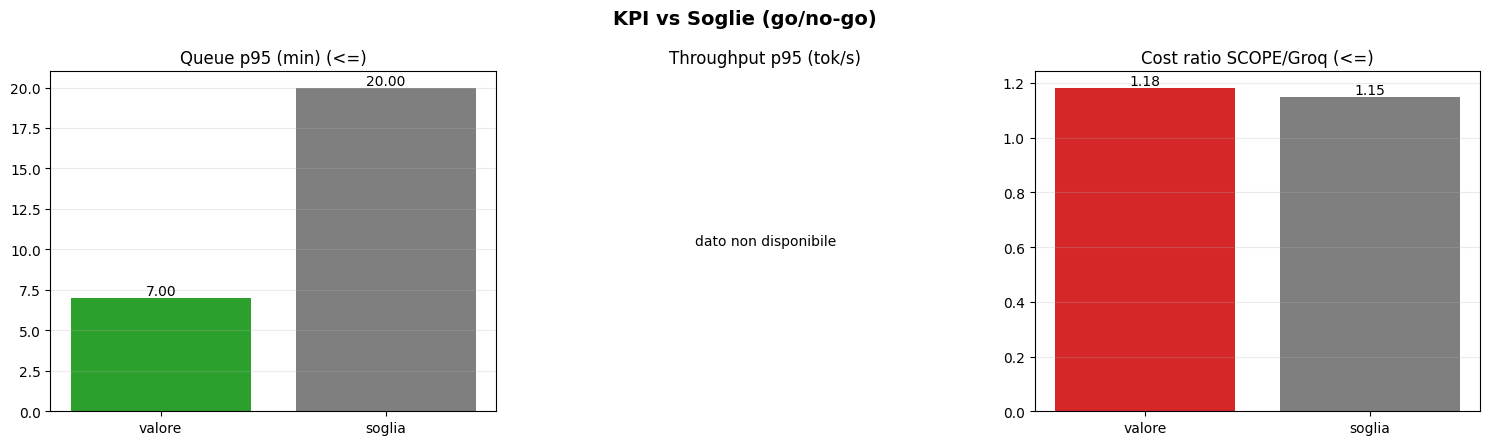

In [19]:
import json
from pathlib import Path

try:
    import matplotlib.pyplot as plt
except Exception as exc:
    raise RuntimeError("Matplotlib non disponibile nel kernel corrente") from exc

report_path = OUTPUT_DIR / "kpi_decision_report.json"
if not report_path.exists():
    print(f"Report KPI non trovato: {report_path}")
else:
    report = json.loads(report_path.read_text(encoding="utf-8"))
    kpi = report.get("kpi", {})
    thresholds = report.get("thresholds", {})

    metrics = [
        {
            "label": "Queue p95 (min)",
            "value": kpi.get("queue_wait_p95_min"),
            "threshold": thresholds.get("queue_wait_p95_max_min"),
            "rule": "<=",
        },
        {
            "label": "Throughput p95 (tok/s)",
            "value": kpi.get("throughput_p95_tps"),
            "threshold": thresholds.get("throughput_p95_min_tps"),
            "rule": ">=",
        },
        {
            "label": "Cost ratio SCOPE/Groq",
            "value": kpi.get("scope_vs_groq_cost_ratio"),
            "threshold": thresholds.get("scope_vs_groq_cost_ratio_max"),
            "rule": "<=",
        },
    ]

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
    fig.suptitle("KPI vs Soglie (go/no-go)", fontsize=14, fontweight="bold")

    for ax, m in zip(axes, metrics):
        value = m["value"]
        threshold = m["threshold"]
        rule = m["rule"]

        if value is None or threshold is None:
            ax.text(0.5, 0.5, "dato non disponibile", ha="center", va="center")
            ax.set_title(m["label"])
            ax.axis("off")
            continue

        ok = (value <= threshold) if rule == "<=" else (value >= threshold)
        color_value = "#2ca02c" if ok else "#d62728"

        ax.bar(["valore", "soglia"], [value, threshold], color=[color_value, "#7f7f7f"])
        ax.set_title(f"{m['label']} ({rule})")
        ax.grid(axis="y", alpha=0.25)
        ax.text(0, value, f"{value:.2f}", ha="center", va="bottom")
        ax.text(1, threshold, f"{threshold:.2f}", ha="center", va="bottom")

    plt.tight_layout()
    plt.show()

## Benchmark reale multi-provider: Groq vs SCOPE (no simulazione)

Questa sezione esegue un confronto reale sugli stessi prompt legali tra provider e modelli multipli.

Regole adottate:
- NESSUNA simulazione: non esiste dry-run in queste celle.
- Groq usa i modelli gia usati in LexCausa.
- SCOPE usa gli stessi modelli + modelli extra (es. maverick, scout, deepseek, gpt-oss) se disponibili sul tuo endpoint.

Output prodotti:
- log per prompt/provider/modello con latenza e token/s
- riepilogo aggregato per provider::modello (media e p95)
- salvataggio su `OUTPUT_DIR/ab_results.json`
- aggiornamento di `OUTPUT_DIR/model_throughput_log.json` (utile per KPI)

Prerequisiti minimi:
- `GROQ_API_KEY` per Groq
- `SCOPE_API_KEY` per endpoint SCOPE (o chiave equivalente)
- endpoint SCOPE OpenAI-compatible configurato in `AB_CONFIG`
- opzionale: `SCOPE_EXTRA_HEADERS_JSON` per header custom in formato JSON (`{"Header":"Value"}`)

Se un provider/modello non e configurato correttamente, la riga viene marcata come `error` nel report, senza interrompere tutto il benchmark.

In [15]:
# Questa cella usa SOLO la configurazione centrale definita nel setup unico.

if "AB_CONFIG" not in globals() or "LEGAL_PROMPTS" not in globals():
    raise RuntimeError("Esegui prima la cella di setup unico.")

print("AB config (centralizzata, real-only):")
print(json.dumps({
    "temperature": AB_CONFIG["temperature"],
    "max_tokens": AB_CONFIG["max_tokens"],
    "timeout_s": AB_CONFIG["timeout_s"],
}, indent=2))

print("Provider attivi:")
for provider_name, provider_cfg in AB_CONFIG["providers"].items():
    if not provider_cfg.get("enabled", False):
        continue
    endpoint = str(provider_cfg.get("endpoint", "")).strip()
    api_key_env = str(provider_cfg.get("api_key_env", "")).strip()
    models = [str(m).strip() for m in provider_cfg.get("models", []) if str(m).strip()]

    endpoint_status = "OK"
    if not endpoint:
        endpoint_status = "MISSING"
    elif "INSERISCI_ENDPOINT_SCOPE" in endpoint:
        endpoint_status = "PLACEHOLDER"

    key_status = "SET" if os.getenv(api_key_env, "").strip() else "MISSING"

    print(
        f"- {provider_name}: models={len(models)} | endpoint={endpoint_status} | {api_key_env}={key_status}"
    )

print(f"Prompt legali caricati: {len(LEGAL_PROMPTS)}")
print(f"Output dir: {OUTPUT_DIR}")

AB config (centralizzata, real-only):
{
  "temperature": 0.2,
  "max_tokens": 768,
  "timeout_s": 180
}
Provider attivi:
- groq: models=4 | endpoint=OK | GROQ_API_KEY=MISSING
- scope: models=8 | endpoint=PLACEHOLDER | SCOPE_API_KEY=MISSING
Prompt legali caricati: 8
Output dir: /Users/l.catello/Library/Mobile Documents/com~apple~CloudDocs/Magistrale Ingegneria Informatica/Tesi/LexCausa/notebooks/.scope_hpc_outputs


In [16]:
import time

if "mean_or_none" not in globals():
    def mean_or_none(values):
        if not values:
            return None
        return float(sum(values) / len(values))

if "p95_or_none" not in globals():
    def p95_or_none(values):
        if not values:
            return None
        s = sorted(values)
        idx = max(0, min(len(s) - 1, int((0.95 * len(s)) - 1)))
        return float(s[idx])

def parse_extra_headers(provider_cfg: dict) -> dict:
    header_env = str(provider_cfg.get("extra_headers_env", "")).strip()
    if not header_env:
        return {}
    raw = os.getenv(header_env, "").strip()
    if not raw:
        return {}
    try:
        parsed = json.loads(raw)
    except Exception as exc:
        raise RuntimeError(f"JSON non valido in {header_env}: {exc}") from exc
    if not isinstance(parsed, dict):
        raise RuntimeError(f"{header_env} deve contenere un oggetto JSON")
    return {str(k): str(v) for k, v in parsed.items()}

def provider_request_headers(provider_name: str, provider_cfg: dict) -> dict:
    api_key_env = str(provider_cfg.get("api_key_env", "")).strip()
    api_key = os.getenv(api_key_env, "").strip()
    if not api_key:
        raise RuntimeError(f"[{provider_name}] manca variabile ambiente {api_key_env}")

    headers = {
        "Content-Type": "application/json",
        "Authorization": f"Bearer {api_key}",
    }
    headers.update(parse_extra_headers(provider_cfg))
    return headers

def call_openai_compatible(prompt: str, model: str, provider_name: str, provider_cfg: dict):
    endpoint = str(provider_cfg.get("endpoint", "")).strip()
    if not endpoint:
        raise RuntimeError(f"[{provider_name}] endpoint vuoto")
    if "INSERISCI_ENDPOINT_SCOPE" in endpoint:
        raise RuntimeError(f"[{provider_name}] endpoint placeholder non sostituito")

    payload = {
        "model": model,
        "messages": [
            {"role": "system", "content": AB_CONFIG["system_prompt"]},
            {"role": "user", "content": prompt}
        ],
        "temperature": AB_CONFIG["temperature"],
        "max_tokens": AB_CONFIG["max_tokens"]
    }

    headers = provider_request_headers(provider_name, provider_cfg)
    body = json.dumps(payload).encode("utf-8")
    req = urllib.request.Request(
        endpoint,
        data=body,
        method="POST",
        headers=headers,
    )

    t0 = time.perf_counter()
    try:
        with urllib.request.urlopen(req, timeout=AB_CONFIG["timeout_s"]) as resp:
            raw = resp.read().decode("utf-8")
    except urllib.error.HTTPError as exc:
        detail = exc.read().decode("utf-8", errors="ignore")
        raise RuntimeError(f"HTTPError {exc.code}: {detail}") from exc
    except urllib.error.URLError as exc:
        raise RuntimeError(f"URLError: {exc}") from exc
    latency_s = time.perf_counter() - t0

    data = json.loads(raw)
    choices = data.get("choices", [])
    if not choices:
        raise RuntimeError(f"Risposta senza choices: {data}")

    text = choices[0].get("message", {}).get("content", "")
    usage = data.get("usage", {})
    completion_tokens = int(usage.get("completion_tokens", 0))
    if completion_tokens <= 0:
        completion_tokens = max(1, len(text.split()))

    return {
        "text": text,
        "latency_s": latency_s,
        "completion_tokens": completion_tokens,
        "tokens_per_second": completion_tokens / max(latency_s, 1e-9)
    }

def active_provider_models(config: dict):
    out = []
    for provider_name, provider_cfg in config.get("providers", {}).items():
        if not bool(provider_cfg.get("enabled", False)):
            continue
        models = [str(m).strip() for m in provider_cfg.get("models", []) if str(m).strip()]
        for model in models:
            out.append((provider_name, provider_cfg, model))
    return out

def run_multi_provider_benchmark(prompts, config: dict):
    rows = []
    combos = active_provider_models(config)
    for i, prompt in enumerate(prompts, start=1):
        for provider_name, provider_cfg, model in combos:
            try:
                result = call_openai_compatible(
                    prompt=prompt,
                    model=model,
                    provider_name=provider_name,
                    provider_cfg=provider_cfg,
                )
                rows.append({
                    "prompt_id": i,
                    "prompt": prompt,
                    "provider": provider_name,
                    "model": model,
                    "status": "ok",
                    **result,
                })
            except Exception as exc:
                rows.append({
                    "prompt_id": i,
                    "prompt": prompt,
                    "provider": provider_name,
                    "model": model,
                    "status": "error",
                    "error": str(exc),
                })
    return rows

def summarize_multi_provider(rows):
    grouped = {}
    for row in rows:
        key = f"{row.get('provider')}::{row.get('model')}"
        grouped.setdefault(key, []).append(row)

    by_provider_model = {}
    for key, items in grouped.items():
        ok_items = [r for r in items if r.get("status") == "ok"]
        err_items = [r for r in items if r.get("status") != "ok"]
        lat = [float(r.get("latency_s", 0.0)) for r in ok_items]
        tps = [float(r.get("tokens_per_second", 0.0)) for r in ok_items]
        by_provider_model[key] = {
            "n_total": len(items),
            "n_ok": len(ok_items),
            "n_error": len(err_items),
            "latency_mean_s": mean_or_none(lat),
            "latency_p95_s": p95_or_none(lat),
            "tps_mean": mean_or_none(tps),
            "tps_p95": p95_or_none(tps),
            "last_error": err_items[-1].get("error") if err_items else None,
        }

    return {
        "global": {
            "total_calls": len(rows),
            "ok_calls": sum(1 for r in rows if r.get("status") == "ok"),
            "error_calls": sum(1 for r in rows if r.get("status") != "ok"),
        },
        "by_provider_model": by_provider_model,
    }

ab_rows = run_multi_provider_benchmark(LEGAL_PROMPTS, AB_CONFIG)
ab_summary = summarize_multi_provider(ab_rows)

ab_result = {
    "config": AB_CONFIG,
    "prompts": LEGAL_PROMPTS,
    "summary": ab_summary,
    "rows": ab_rows,
}

ab_path = OUTPUT_DIR / "ab_results.json"
ab_path.write_text(json.dumps(ab_result, indent=2), encoding="utf-8")

# Aggiorna throughput log per KPI globali (solo chiamate riuscite)
thr_rows = []
for r in ab_rows:
    if r.get("status") != "ok":
        continue
    thr_rows.append({
        "provider": r.get("provider"),
        "model": r.get("model"),
        "generated_tokens": r.get("completion_tokens"),
        "elapsed_s": r.get("latency_s"),
    })

thr_path = OUTPUT_DIR / "model_throughput_log.json"
thr_path.write_text(json.dumps(thr_rows, indent=2), encoding="utf-8")

print("Benchmark multi-provider completato")
print(json.dumps(ab_summary, indent=2))
print(f"Salvato: {ab_path}")
print(f"Aggiornato throughput: {thr_path}")

Benchmark multi-provider completato
{
  "global": {
    "total_calls": 96,
    "ok_calls": 0,
    "error_calls": 96
  },
  "by_provider_model": {
    "groq::qwen/qwen3-32b": {
      "n_total": 8,
      "n_ok": 0,
      "n_error": 8,
      "latency_mean_s": null,
      "latency_p95_s": null,
      "tps_mean": null,
      "tps_p95": null,
      "last_error": "[groq] manca variabile ambiente GROQ_API_KEY"
    },
    "groq::llama-3.3-70b-versatile": {
      "n_total": 8,
      "n_ok": 0,
      "n_error": 8,
      "latency_mean_s": null,
      "latency_p95_s": null,
      "tps_mean": null,
      "tps_p95": null,
      "last_error": "[groq] manca variabile ambiente GROQ_API_KEY"
    },
    "groq::openai/gpt-oss-20b": {
      "n_total": 8,
      "n_ok": 0,
      "n_error": 8,
      "latency_mean_s": null,
      "latency_p95_s": null,
      "tps_mean": null,
      "tps_p95": null,
      "last_error": "[groq] manca variabile ambiente GROQ_API_KEY"
    },
    "groq::openai/gpt-oss-120b": {
     

## Grafici benchmark (explainability veloce)

Vista rapida per provider e modello:
- tasso successo chiamate
- latenza media
- throughput medio (token/s)

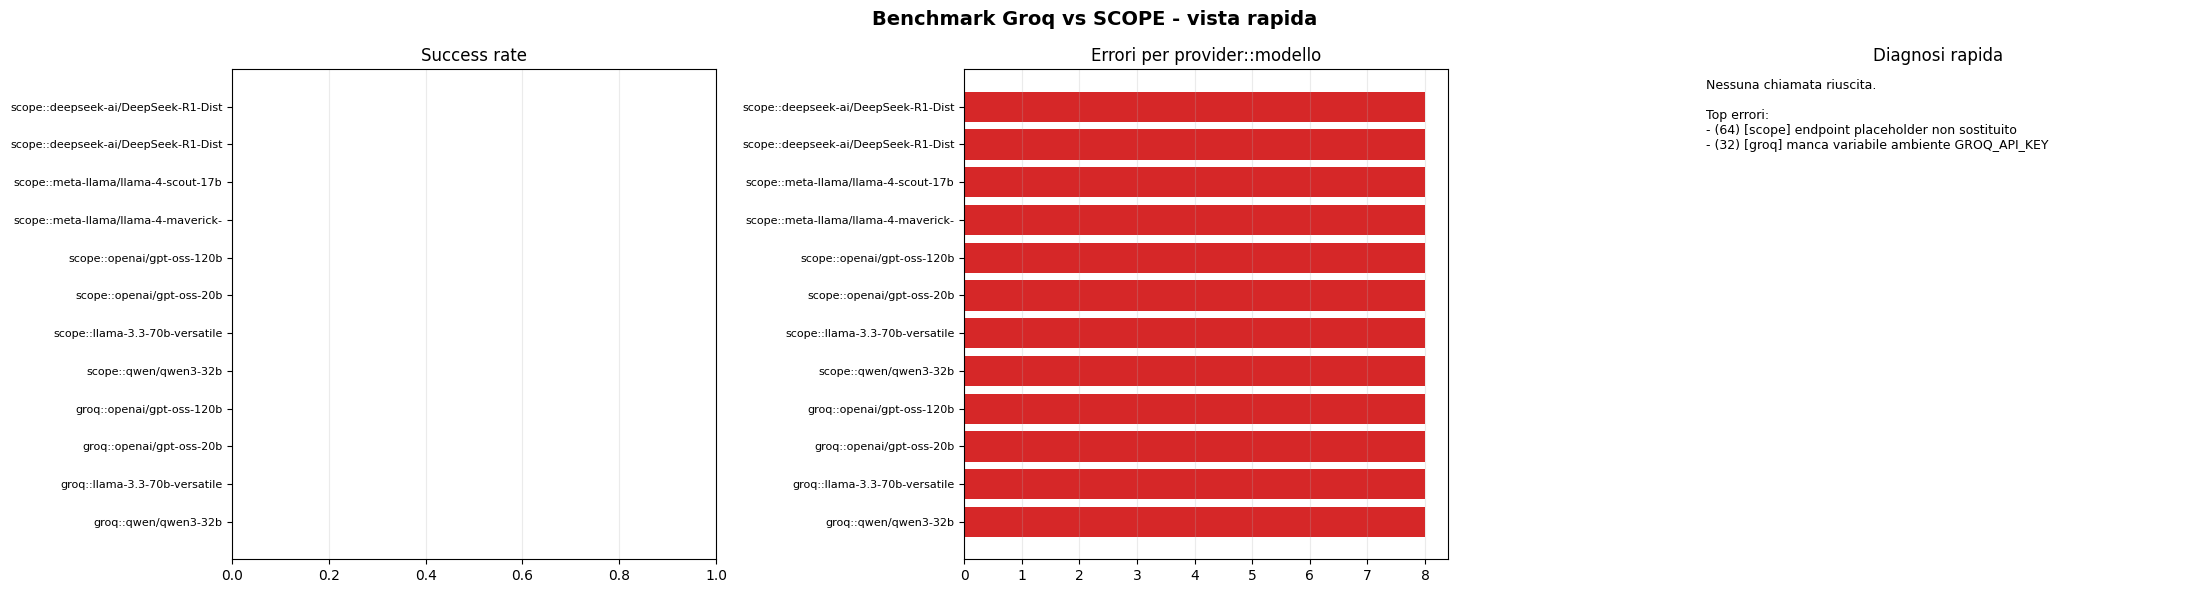

In [20]:
import json
from collections import Counter
from pathlib import Path

try:
    import matplotlib.pyplot as plt
except Exception as exc:
    raise RuntimeError("Matplotlib non disponibile nel kernel corrente") from exc

ab_path = OUTPUT_DIR / "ab_results.json"
if not ab_path.exists():
    print(f"Report benchmark non trovato: {ab_path}")
else:
    ab = json.loads(ab_path.read_text(encoding="utf-8"))
    by_pm = ab.get("summary", {}).get("by_provider_model", {})

    if not by_pm:
        print("Nessun dato nel riepilogo benchmark")
    else:
        labels = list(by_pm.keys())
        success_rate = []
        n_error = []
        tps_mean = []

        for k in labels:
            row = by_pm.get(k, {})
            n_total = float(row.get("n_total", 0) or 0)
            n_ok = float(row.get("n_ok", 0) or 0)
            n_err = float(row.get("n_error", 0) or 0)
            success_rate.append((n_ok / n_total) if n_total > 0 else 0.0)
            n_error.append(n_err)
            tps_mean.append(float(row.get("tps_mean")) if row.get("tps_mean") is not None else 0.0)

        short_labels = [
            f"{x.split('::')[0]}::{x.split('::')[1][:28]}"
            if "::" in x else x[:34]
            for x in labels
        ]

        y = list(range(len(short_labels)))

        fig, axes = plt.subplots(1, 3, figsize=(22, max(6, len(short_labels) * 0.45)))
        fig.suptitle("Benchmark Groq vs SCOPE - vista rapida", fontsize=14, fontweight="bold")

        colors_success = ["#2ca02c" if s >= 0.99 else ("#ff7f0e" if s > 0 else "#d62728") for s in success_rate]
        axes[0].barh(y, success_rate, color=colors_success)
        axes[0].set_yticks(y)
        axes[0].set_yticklabels(short_labels, fontsize=8)
        axes[0].set_xlim(0, 1)
        axes[0].set_title("Success rate")
        axes[0].grid(axis="x", alpha=0.25)

        axes[1].barh(y, n_error, color="#d62728")
        axes[1].set_yticks(y)
        axes[1].set_yticklabels(short_labels, fontsize=8)
        axes[1].set_title("Errori per provider::modello")
        axes[1].grid(axis="x", alpha=0.25)

        ok_any = any(v > 0 for v in tps_mean)
        if ok_any:
            axes[2].barh(y, tps_mean, color="#9467bd")
            axes[2].set_yticks(y)
            axes[2].set_yticklabels(short_labels, fontsize=8)
            axes[2].set_title("Throughput medio (token/s)")
            axes[2].grid(axis="x", alpha=0.25)
        else:
            all_rows = ab.get("rows", [])
            errors = [str(r.get("error", "errore non classificato")) for r in all_rows if r.get("status") != "ok"]
            top_errors = Counter(errors).most_common(3)
            msg = "Nessuna chiamata riuscita.\n\nTop errori:\n"
            for err, cnt in top_errors:
                msg += f"- ({cnt}) {err[:90]}\n"
            axes[2].text(0.02, 0.98, msg.strip(), va="top", ha="left", fontsize=9)
            axes[2].set_title("Diagnosi rapida")
            axes[2].axis("off")

        plt.tight_layout()
        plt.show()

## Strategia modelli per confronto Groq vs SCOPE

Obiettivo pratico:
- Groq: valutare SOLO i modelli oggi usati in LexCausa.
- SCOPE: valutare gli stessi modelli + modelli extra non piu disponibili su Groq Cloud (es. maverick, scout, deepseek, gpt-oss).

Set consigliato iniziale:
1. Groq (LexCausa):
   - `qwen/qwen3-32b`
   - `llama-3.3-70b-versatile`
   - `openai/gpt-oss-20b`
   - `openai/gpt-oss-120b`
2. SCOPE:
   - tutti i modelli Groq sopra
   - `meta-llama/llama-4-maverick-17b-128e-instruct`
   - `meta-llama/llama-4-scout-17b-16e-instruct`
   - `deepseek-ai/DeepSeek-R1-Distill-Qwen-14B`
   - `deepseek-ai/DeepSeek-R1-Distill-Llama-8B`

Nota operativa:
- I nomi modello devono combaciare con il catalogo del tuo endpoint SCOPE.
- Se un modello non esiste o non e disponibile, il benchmark lo marca come errore ma continua sugli altri modelli.

In [13]:
def complexity_score(prompt: str) -> float:
    text = prompt.lower()
    triggers = [
        "bilanci", "eccezion", "causal", "concorso", "revoca", "autotutela",
        "motivazione", "prescrizione", "pluralita", "multi-step", "conflitto"
    ]
    score = 0.0
    for t in triggers:
        if t in text:
            score += 1.0
    score += min(len(prompt) / 500.0, 2.0)
    return score

def choose_model_for_provider(prompt: str, provider: str, threshold: float = 2.5):
    s = complexity_score(prompt)
    provider = str(provider).strip().lower()

    # baseline comuni a LexCausa
    groq_fast = "qwen/qwen3-32b"
    groq_reasoning = "openai/gpt-oss-120b"

    # su SCOPE puoi usare modelli extra se disponibili
    scope_fast = "qwen/qwen3-32b"
    scope_reasoning = "deepseek-ai/DeepSeek-R1-Distill-Qwen-14B"

    if provider == "scope":
        return (scope_reasoning if s >= threshold else scope_fast), s
    return (groq_reasoning if s >= threshold else groq_fast), s

print("Router demo Groq vs SCOPE:")
for p in LEGAL_PROMPTS[:5]:
    groq_model, groq_score = choose_model_for_provider(p, "groq", threshold=2.5)
    scope_model, scope_score = choose_model_for_provider(p, "scope", threshold=2.5)
    print(f"- score={groq_score:.2f} | groq={groq_model} | scope={scope_model} :: {p[:90]}...")

Router demo Groq vs SCOPE:
- score=2.22 | groq=qwen/qwen3-32b | scope=qwen/qwen3-32b :: Valuta se la revoca in autotutela e adeguatamente motivata in presenza di affidamento qual...
- score=0.23 | groq=qwen/qwen3-32b | scope=qwen/qwen3-32b :: Nel caso di inadempimento contrattuale, quando e proporzionata la risoluzione rispetto all...
- score=1.21 | groq=qwen/qwen3-32b | scope=qwen/qwen3-32b :: Esamina il nesso causale in responsabilita da custodia quando interviene un fattore estern...
- score=0.19 | groq=qwen/qwen3-32b | scope=qwen/qwen3-32b :: Quando la violazione procedimentale e non invalidante ai sensi dell art. 21-octies L. 241/...
- score=0.17 | groq=qwen/qwen3-32b | scope=qwen/qwen3-32b :: Confronta soglia probatoria penale e civile in un caso con fatti in parte sovrapposti....
